In [1]:
# Basic imports
from HARK.models import IndShockConsumerType
import matplotlib.pyplot as plt

In [2]:
# Define grids
wealth_grid = {"min": 0.0, "max": 40.0, "N": 200, "order": 2.0}
con_grid = {"min": 0.0, "max": 10.0, "N": 201}
my_grid_specs = {"kNrm": wealth_grid, "cNrm": con_grid}

In [3]:
# Make a life-cycle agent
T = 50
trivial_LC_params = {
    "PermGroFac": T * [1.0],
    "PermShkStd": T * [0.1],
    "TranShkStd": T * [0.1],
    "LivPrb": T * [0.99],
    "Rfree": T * [1.03],
    "T_cycle": T,
}
MyType = IndShockConsumerType(**trivial_LC_params)

In [4]:
# Define a simple function for plotting SSJs
def plot_SSJ(jac, S, outcome, shock, t_max=None):
    top = jac.shape[0] + 1 if t_max is None else t_max
    if type(S) is int:
        S = [S]
    for s in S:
        plt.plot(jac[:, s], "-", label="s=" + str(s))
    plt.legend()
    plt.xlabel(r"time $t$")
    plt.ylabel("rate of change of " + outcome)
    plt.title("SSJ for " + outcome + " with respect to " + shock + r" at time $s$")
    plt.tight_layout()
    plt.xlim(-1, top + 1)
    plt.show()

In [5]:
# Make HA-SSJs
J_A_R, J_C_R = MyType.make_basic_SSJ(
    "Rfree",
    ["aNrm", "cNrm"],
    grids=my_grid_specs,
    verbose=True,
    offset=True,
    norm="PermShk",
)

Solving the long run model took 0.041 seconds.
Making the transition matrix for the long run model took 2.750 seconds.
Finding the long run steady state took 0.040 seconds.
Constructing expectation vectors took 0.375 seconds.
Making fake news arrays for each period of the problem took 25.645 seconds.
Constructing the sequence space Jacobians took 1.030 seconds.


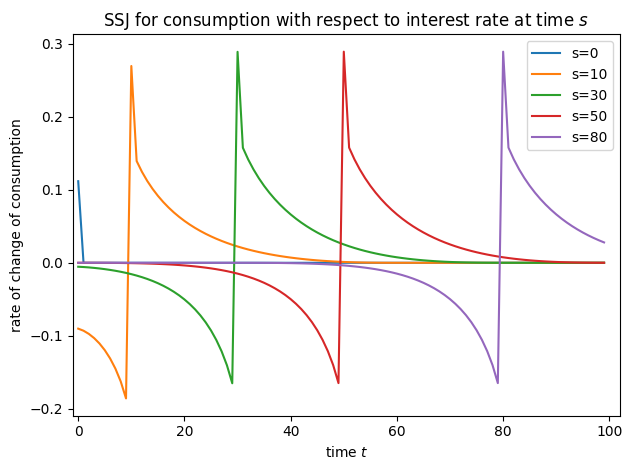

In [6]:
# plt.plot(out[0,20,:,35])
# plt.show()

# a_grid = make_exponential_grid(0., 40., 200, order=2.0)
# plt.plot(out[0][:,0,50])

plot_SSJ(J_C_R, [0, 10, 30, 50, 80], "consumption", "interest rate")

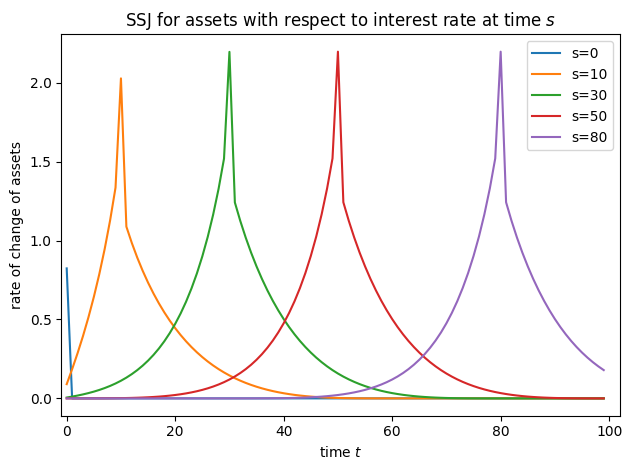

In [7]:
plot_SSJ(J_A_R, [0, 10, 30, 50, 80], "assets", "interest rate")